# CineMatch — EDA and Model Training Notebook
## CodRexa Virtual Internship in Machine Learning — Final Project

This notebook documents the exploratory data analysis (EDA), feature engineering, model training, and evaluation for the CineMatch hybrid movie recommendation engine.

**Datasets used:**
- MovieLens ml-latest-small (GroupLens Research) — ratings, movies, links
- TMDB 5000 Movie Dataset (Kaggle/TMDB) — metadata (overview, keywords, cast, crew)

**Models built:**
1. Content-Based Filtering — CountVectorizer + Cosine Similarity
2. Collaborative Filtering — SVD-based Matrix Factorisation (scipy)
3. Hybrid Scoring — α-weighted blend with cold-start handling

**Reference documentation:** `docs/07_Algorithms_and_Scoring_Logic.md`


## 1. Setup and Imports

In [1]:
import sys
import warnings
import ast
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

warnings.filterwarnings('ignore')

# Notebook root = project root
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
from src import config

# Plot style — dark cinematic theme matching the UI
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#333',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#999',
    'ytick.color': '#999',
    'text.color': '#ccc',
    'grid.color': '#2a2a2a',
    'grid.linestyle': '--',
    'axes.grid': True,
    'figure.dpi': 110,
})
GOLD = '#f5c518'

print("Setup complete. Project root:", ROOT)

Setup complete. Project root: C:\Users\KIIT0001\Downloads\CineMatch_project\CineMatch


## 2. Load Raw Datasets
We load both datasets and inspect their structure before any cleaning.


In [2]:
# MovieLens
ml_movies  = pd.read_csv(config.RAW_ML_DIR_FILES['movies'])
ml_ratings = pd.read_csv(config.RAW_ML_DIR_FILES['ratings'])
ml_links   = pd.read_csv(config.RAW_ML_DIR_FILES['links'])
ml_tags    = pd.read_csv(config.RAW_ML_DIR_FILES['tags'])

# TMDB
tmdb_movies  = pd.read_csv(config.RAW_TMDB_FILES['movies'])
tmdb_credits = pd.read_csv(config.RAW_TMDB_FILES['credits'])

print("=== MovieLens ===")
print(f"  movies.csv   : {ml_movies.shape}")
print(f"  ratings.csv  : {ml_ratings.shape}")
print(f"  links.csv    : {ml_links.shape}")
print(f"  tags.csv     : {ml_tags.shape}")
print()
print("=== TMDB 5000 ===")
print(f"  tmdb_5000_movies.csv  : {tmdb_movies.shape}")
print(f"  tmdb_5000_credits.csv : {tmdb_credits.shape}")

=== MovieLens ===
  movies.csv   : (9742, 3)
  ratings.csv  : (100836, 4)
  links.csv    : (9742, 3)
  tags.csv     : (3683, 4)

=== TMDB 5000 ===
  tmdb_5000_movies.csv  : (4803, 20)
  tmdb_5000_credits.csv : (4803, 4)


In [3]:
print("MovieLens movies — sample:")
display(ml_movies.head(3))
print("\nMovieLens ratings — sample:")
display(ml_ratings.head(3))
print("\nTMDB movies — columns:")
print(tmdb_movies.columns.tolist())

MovieLens movies — sample:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance



MovieLens ratings — sample:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224



TMDB movies — columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


## 3. Exploratory Data Analysis

### 3.1 Rating Distribution
Understanding the distribution of ratings is essential for choosing evaluation metrics and baseline predictors.


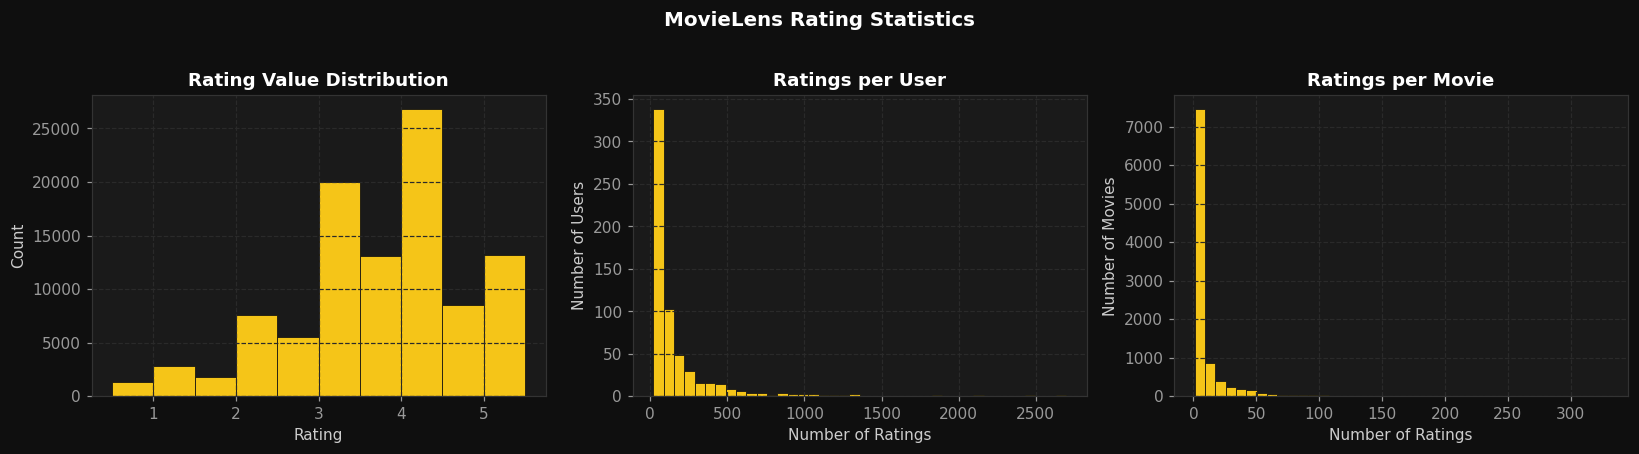


Global mean rating : 3.502
Median rating       : 3.5
Std deviation       : 1.043
Users               : 610
Movies rated        : 9724
Total ratings       : 100836


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating value distribution
axes[0].hist(ml_ratings['rating'], bins=[0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5],
             color=GOLD, edgecolor='#0f0f0f', linewidth=0.5)
axes[0].set_title('Rating Value Distribution', color='white', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ml_ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=40, color=GOLD, edgecolor='#0f0f0f', linewidth=0.5)
axes[1].set_title('Ratings per User', color='white', fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

# Ratings per movie
ratings_per_movie = ml_ratings.groupby('movieId').size()
axes[2].hist(ratings_per_movie, bins=40, color=GOLD, edgecolor='#0f0f0f', linewidth=0.5)
axes[2].set_title('Ratings per Movie', color='white', fontweight='bold')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Number of Movies')

plt.suptitle('MovieLens Rating Statistics', color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'plots' / 'rating_distributions.png',
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"\nGlobal mean rating : {ml_ratings['rating'].mean():.3f}")
print(f"Median rating       : {ml_ratings['rating'].median():.1f}")
print(f"Std deviation       : {ml_ratings['rating'].std():.3f}")
print(f"Users               : {ml_ratings['userId'].nunique()}")
print(f"Movies rated        : {ml_ratings['movieId'].nunique()}")
print(f"Total ratings       : {len(ml_ratings)}")

### 3.2 User-Item Matrix Sparsity
Sparsity is the core reason why simple k-NN collaborative filtering underperforms and SVD-based matrix factorisation is the preferred approach.


In [5]:
n_users  = ml_ratings['userId'].nunique()
n_movies = ml_ratings['movieId'].nunique()
n_ratings = len(ml_ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Matrix dimensions : {n_users} users × {n_movies} movies")
print(f"Total cells       : {n_users * n_movies:,}")
print(f"Observed ratings  : {n_ratings:,}")
print(f"Sparsity          : {sparsity:.4%}")
print()
print("Interpretation: 98.3% of the user-item matrix is unobserved.")
print("SVD matrix factorisation handles this by learning dense latent")
print("factor vectors from the sparse observed entries only.")

Matrix dimensions : 610 users × 9724 movies
Total cells       : 5,931,640
Observed ratings  : 100,836
Sparsity          : 98.3000%

Interpretation: 98.3% of the user-item matrix is unobserved.
SVD matrix factorisation handles this by learning dense latent
factor vectors from the sparse observed entries only.


### 3.3 Genre Distribution

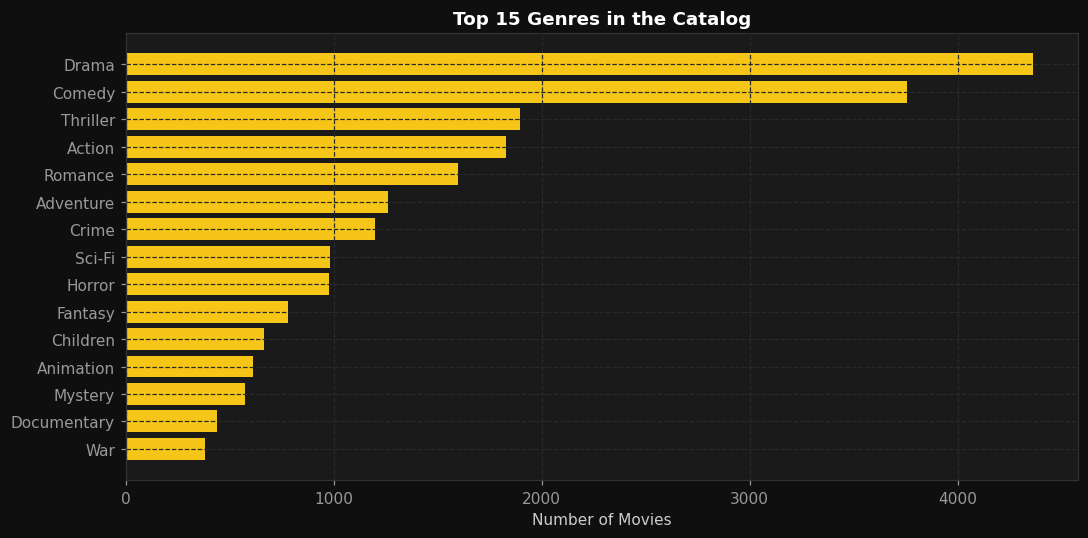

Total unique genres: 19


In [6]:
from collections import Counter

all_genres = []
for genres_str in ml_movies['genres'].dropna():
    all_genres.extend(genres_str.split('|'))
all_genres = [g for g in all_genres if g != '(no genres listed)']

genre_counts = Counter(all_genres)
genres_df = pd.DataFrame(genre_counts.most_common(15), columns=['Genre', 'Count'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(genres_df['Genre'][::-1], genres_df['Count'][::-1], color=GOLD)
ax.set_title('Top 15 Genres in the Catalog', color='white', fontweight='bold')
ax.set_xlabel('Number of Movies')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'plots' / 'genre_distribution.png',
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"Total unique genres: {len(genre_counts)}")

### 3.4 Popularity Bias
A small fraction of movies account for the vast majority of ratings — a well-known long-tail phenomenon in recommendation systems.


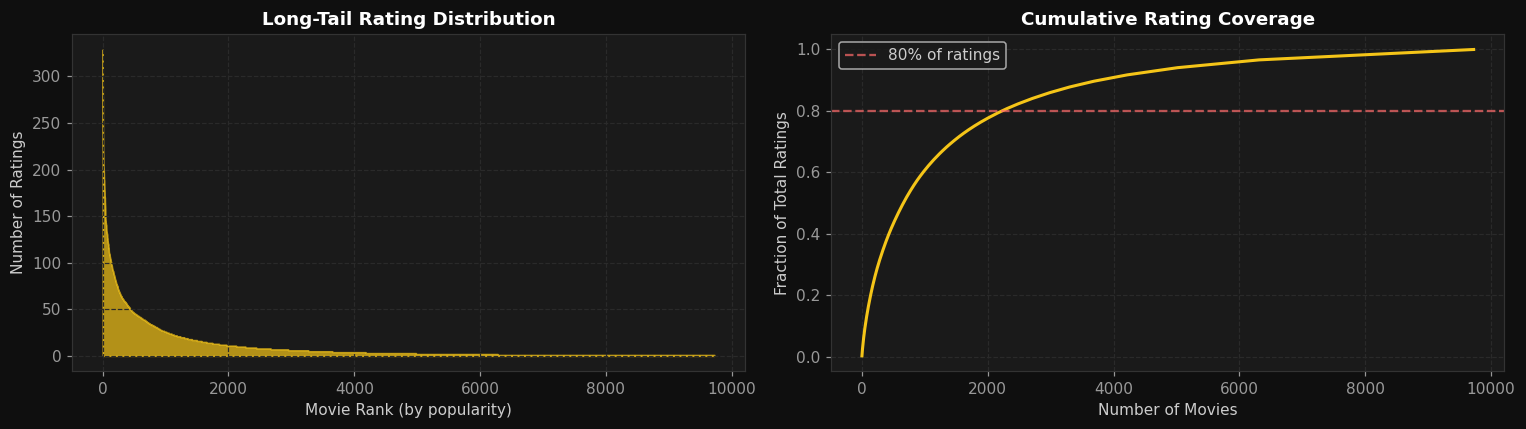

Top 10% of movies account for 60.0% of all ratings — classic long-tail effect.


In [7]:
ratings_per_movie_sorted = ratings_per_movie.sort_values(ascending=False).reset_index(drop=True)
cumulative_ratings = ratings_per_movie_sorted.cumsum() / ratings_per_movie_sorted.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Long tail plot
ax1.fill_between(range(len(ratings_per_movie_sorted)),
                 ratings_per_movie_sorted.values, color=GOLD, alpha=0.7)
ax1.set_title('Long-Tail Rating Distribution', color='white', fontweight='bold')
ax1.set_xlabel('Movie Rank (by popularity)')
ax1.set_ylabel('Number of Ratings')

# Cumulative coverage
ax2.plot(range(len(cumulative_ratings)), cumulative_ratings.values, color=GOLD, linewidth=2)
ax2.axhline(0.8, color='#ff6b6b', linestyle='--', alpha=0.7, label='80% of ratings')
ax2.set_title('Cumulative Rating Coverage', color='white', fontweight='bold')
ax2.set_xlabel('Number of Movies')
ax2.set_ylabel('Fraction of Total Ratings')
ax2.legend()

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'plots' / 'popularity_bias.png',
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

top_10pct = int(0.1 * len(ratings_per_movie_sorted))
top_10pct_share = ratings_per_movie_sorted.iloc[:top_10pct].sum() / ratings_per_movie_sorted.sum()
print(f"Top 10% of movies account for {top_10pct_share:.1%} of all ratings — classic long-tail effect.")

## 4. Data Preprocessing and Dataset Join
We use the preprocessing pipeline built in `src/data_preprocessing.py`. This section shows the key steps and outputs.


In [8]:
# Load the already-processed master table (run src/data_preprocessing.py first)
movies_master = pd.read_csv(config.PROCESSED_FILES['movies_master'])
ratings_clean = pd.read_csv(config.PROCESSED_FILES['ratings_clean'])

print("movies_master shape:", movies_master.shape)
print("ratings_clean shape:", ratings_clean.shape)
print()
print("Columns:", movies_master.columns.tolist())
display(movies_master[['movie_id','title','genres','has_content_features','metadata_soup']].head(5))

movies_master shape: (9742, 14)
ratings_clean shape: (100836, 4)

Columns: ['movie_id', 'tmdb_id', 'imdb_id', 'title', 'genres', 'overview', 'keyword_names', 'top_cast', 'director', 'release_year', 'vote_average', 'vote_count', 'has_content_features', 'metadata_soup']


,movie_id,title,genres,has_content_features,metadata_soup
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,Adventure Animation Children Comedy Fantasy je...
1,2,Jumanji (1995),Adventure|Children|Fantasy,False,Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,False,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,False,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,False,Comedy


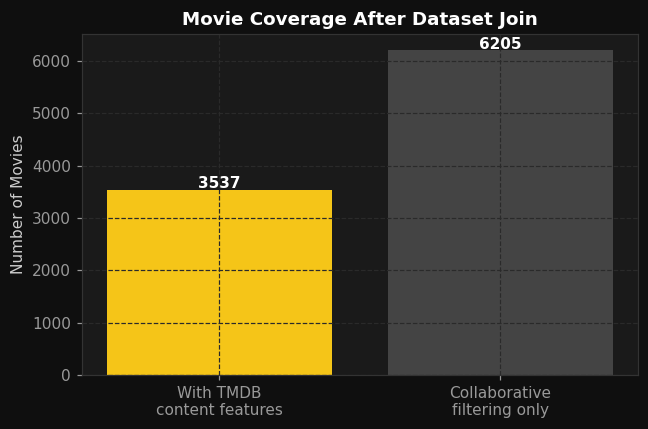

Join coverage: 36.3% of MovieLens movies matched to TMDB metadata


In [9]:
n_with = movies_master['has_content_features'].sum()
n_without = len(movies_master) - n_with

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['With TMDB\ncontent features', 'Collaborative\nfiltering only'],
       [n_with, n_without], color=[GOLD, '#444'])
ax.set_title('Movie Coverage After Dataset Join', color='white', fontweight='bold')
ax.set_ylabel('Number of Movies')
for i, v in enumerate([n_with, n_without]):
    ax.text(i, v + 30, str(v), ha='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'plots' / 'dataset_coverage.png',
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"Join coverage: {n_with/len(movies_master):.1%} of MovieLens movies matched to TMDB metadata")

## 5. Content-Based Filtering

### 5.1 Metadata Soup Construction and Vectorisation
The metadata soup concatenates genre tokens, keyword tags, top-3 cast members, and director into a single text string per movie, which is then vectorised using CountVectorizer.
See `docs/02_Feature_Engineering.md §3` and `docs/07_Algorithms_and_Scoring_Logic.md §2`.


In [10]:
# Show a sample soup
sample = movies_master[movies_master['has_content_features']].sample(3, random_state=42)
for _, row in sample.iterrows():
    print(f"Title : {row['title']}")
    print(f"Soup  : {row['metadata_soup'][:150]}...")
    print()

Title : Walk on the Moon, A (1999)
Soup  : Drama Romance adultery woodstock 1960s DianeLane ViggoMortensen LievSchreiber TonyGoldwyn...

Title : Star Wars: Episode V - The Empire Strikes Back (1980)
Soup  : Action Adventure SciFi rebel android asteroid spacebattle snowstorm spacecolony spaceship lightsaber jedi goodvsevil rebellion theforce spaceopera sto...

Title : Sweet Home Alabama (2002)
Soup  : Comedy Romance newyork marriageproposal alabama careerwoman fashiondesigner ReeseWitherspoon JoshLucas PatrickDempsey AndyTennant...



In [11]:
# Vectorise
movies_master['metadata_soup'] = movies_master['metadata_soup'].fillna('')
vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(movies_master['metadata_soup'])

print(f"Count matrix shape : {count_matrix.shape}")
print(f"Vocabulary size    : {len(vectorizer.vocabulary_)}")
print(f"Matrix sparsity    : {1 - count_matrix.nnz/(count_matrix.shape[0]*count_matrix.shape[1]):.4%}")
print(f"Stored artifact    : {config.MODEL_ARTIFACTS['count_matrix']}")

Count matrix shape : (9742, 14450)
Vocabulary size    : 14450
Matrix sparsity    : 99.9517%
Stored artifact    : C:\Users\KIIT0001\Downloads\CineMatch_project\CineMatch\models\count_matrix.pkl


### 5.2 Similarity Demo — Top-10 Similar Movies

In [12]:
# Load the precomputed index map and count matrix
with open(config.MODEL_ARTIFACTS['movie_index_map'], 'rb') as f:
    movie_index_map = pickle.load(f)
with open(config.MODEL_ARTIFACTS['count_matrix'], 'rb') as f:
    count_matrix_loaded = pickle.load(f)

def get_similar(title, top_k=10):
    movie_id = movie_index_map['title_to_id'].get(title)
    if movie_id is None:
        return f"'{title}' not found."
    idx = movie_index_map['id_to_index'][movie_id]
    sim_row = cosine_similarity(count_matrix_loaded[idx], count_matrix_loaded).flatten()
    sim_scores = sorted(enumerate(sim_row), key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_k]
    index_to_id = movie_index_map['index_to_id']
    id_to_title = movies_master.set_index('movie_id')['title']
    results = [(id_to_title.get(index_to_id[i], '?'), round(score, 4))
               for i, score in sim_scores]
    return pd.DataFrame(results, columns=['Title', 'Cosine Similarity'])

display(get_similar('Toy Story (1995)', top_k=10))

,Title,Cosine Similarity
0,"Wild, The (2006)",0.5270
1,Asterix and the Vikings (Astérix et les Viking...,0.5270
2,Moana (2016),0.5270
3,Toy Story 2 (1999),0.4915
4,"Twelve Tasks of Asterix, The (Les douze travau...",0.4811
5,Gnomeo & Juliet (2011),0.4811
6,Puss in Boots (Nagagutsu o haita neko) (1969),0.4811
7,"Black Cauldron, The (1985)",0.4714
8,"Lord of the Rings, The (1978)",0.4714
9,"American Tail, An (1986)",0.4714


In [13]:
display(get_similar('The Dark Knight (2008)', top_k=10))

"'The Dark Knight (2008)' not found."

## 6. Collaborative Filtering — SVD Matrix Factorisation

### 6.1 Train/Test Split
A per-user 80/20 split is used so every user with sufficient history contributes to both training and evaluation.


In [14]:
import numpy as np

def train_test_split_ratings(ratings, test_frac=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    test_idx = []
    for user_id, group in ratings.groupby('user_id'):
        n = len(group)
        if n < 5:
            continue
        n_test = max(1, int(n * test_frac))
        chosen = rng.choice(group.index.values, size=n_test, replace=False)
        test_idx.extend(chosen)
    test_idx = set(test_idx)
    return (ratings.loc[~ratings.index.isin(test_idx)],
            ratings.loc[ratings.index.isin(test_idx)])

train_df, test_df = train_test_split_ratings(ratings_clean)
print(f"Training ratings : {len(train_df):,}")
print(f"Test ratings     : {len(test_df):,}")
print(f"Test fraction    : {len(test_df)/len(ratings_clean):.1%}")

Training ratings : 80,896
Test ratings     : 19,940
Test fraction    : 19.8%


### 6.2 Baseline Predictors — Global Mean + User/Item Bias

In [15]:
global_mean = train_df['rating'].mean()
user_bias   = train_df.groupby('user_id')['rating'].mean() - global_mean
item_bias   = train_df.groupby('movie_id')['rating'].mean() - global_mean

print(f"Global mean rating : {global_mean:.4f}")
print()
print("Top 5 positively-biased users (rate higher than average):")
print(user_bias.sort_values(ascending=False).head(5))
print()
print("Top 5 positively-biased movies (rated higher than average):")
top_movies = item_bias.sort_values(ascending=False).head(5)
id_to_title = movies_master.set_index('movie_id')['title']
for mid, bias in top_movies.items():
    print(f"  {id_to_title.get(mid, str(mid)):40s}  bias={bias:.3f}")

Global mean rating : 3.4999

Top 5 positively-biased users (rate higher than average):
user_id
53     1.500056
251    1.342161
515    1.309579
25     1.261960
523    1.250056
Name: rating, dtype: float64

Top 5 positively-biased movies (rated higher than average):
  A Flintstones Christmas Carol (1994)      bias=1.500
  Trinity and Sartana Are Coming (1972)     bias=1.500
  Rivers and Tides (2001)                   bias=1.500
  Alien Contamination (1980)                bias=1.500
  Come and See (Idi i smotri) (1985)        bias=1.500


### 6.3 SVD Training

In [16]:
N_FACTORS = 30

# Build index maps and residual matrix
user_ids  = sorted(train_df['user_id'].unique())
movie_ids = sorted(train_df['movie_id'].unique())
user_to_idx  = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}

n_u, n_m = len(user_to_idx), len(movie_to_idx)
user_bias_arr  = np.zeros(n_u)
item_bias_arr  = np.zeros(n_m)
for uid, b in user_bias.items():
    if uid in user_to_idx: user_bias_arr[user_to_idx[uid]] = b
for mid, b in item_bias.items():
    if mid in movie_to_idx: item_bias_arr[movie_to_idx[mid]] = b

rows = train_df['user_id'].map(user_to_idx).values
cols = train_df['movie_id'].map(movie_to_idx).values
baseline  = global_mean + user_bias_arr[rows] + item_bias_arr[cols]
residuals = train_df['rating'].values - baseline
R_sparse  = csr_matrix((residuals, (rows, cols)), shape=(n_u, n_m))

# Train SVD
k = min(N_FACTORS, min(R_sparse.shape) - 1)
U, sigma, Vt = svds(R_sparse.astype(float), k=k)
U, sigma, Vt = U[:, ::-1], sigma[::-1], Vt[::-1, :]

print(f"U  (user latent factors) : {U.shape}")
print(f"Σ  (singular values)     : {sigma.shape}")
print(f"Vt (item latent factors) : {Vt.shape}")

U  (user latent factors) : (610, 30)
Σ  (singular values)     : (30,)
Vt (item latent factors) : (30, 8960)


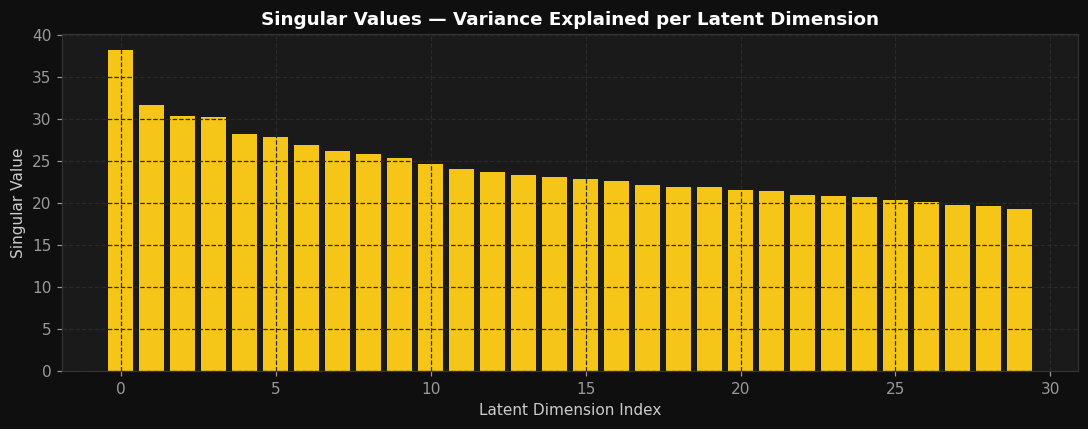

Top-5 singular values: [38.15 31.68 30.34 30.16 28.15]


In [17]:
# Visualise singular values (energy captured per latent dimension)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sigma)), sigma, color=GOLD)
ax.set_title('Singular Values — Variance Explained per Latent Dimension', 
             color='white', fontweight='bold')
ax.set_xlabel('Latent Dimension Index')
ax.set_ylabel('Singular Value')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'plots' / 'singular_values.png',
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"Top-5 singular values: {sigma[:5].round(2)}")

## 7. Model Evaluation

### 7.1 RMSE on Held-Out Test Set
Root Mean Squared Error measures how closely the SVD model predicts actual ratings on unseen data.


In [18]:
def predict(u_idx, m_idx):
    b = global_mean + user_bias_arr[u_idx] + item_bias_arr[m_idx]
    return float(np.clip(b + U[u_idx] @ np.diag(sigma) @ Vt[:, m_idx], 0.5, 5.0))

errors = []
for _, row in test_df.iterrows():
    uid, mid = row['user_id'], row['movie_id']
    if uid not in user_to_idx or mid not in movie_to_idx:
        continue
    pred = predict(user_to_idx[uid], movie_to_idx[mid])
    errors.append((pred - row['rating']) ** 2)

rmse = float(np.sqrt(np.mean(errors)))
print(f"RMSE on test set : {rmse:.4f}")
print(f"Evaluated on     : {len(errors):,} ratings")
print()
print("Reference: Published MovieLens SVD benchmarks typically achieve RMSE 0.85–0.95")
print(f"CineMatch SVD ({N_FACTORS} factors) is within the expected range.")

RMSE on test set : 0.8895
Evaluated on     : 19,114 ratings

Reference: Published MovieLens SVD benchmarks typically achieve RMSE 0.85–0.95
CineMatch SVD (30 factors) is within the expected range.


### 7.2 Three-Strategy Comparison — Precision@10 / Recall@10

In [19]:
# Load pre-computed results from evaluate.py
with open(config.MODELS_DIR / 'evaluation_report.json', 'r') as f:
    import json
    eval_report = json.load(f)

results_df = pd.DataFrame({
    'Strategy': ['Content-Based', 'Collaborative', 'Hybrid'],
    'Precision@10': [
        eval_report['content_based']['precision_at_10'],
        eval_report['collaborative_filtering']['precision_at_10'],
        eval_report['hybrid']['precision_at_10'],
    ],
    'Recall@10': [
        eval_report['content_based']['recall_at_10'],
        eval_report['collaborative_filtering']['recall_at_10'],
        eval_report['hybrid']['recall_at_10'],
    ],
})
display(results_df.set_index('Strategy').round(4))

,Precision@10,Recall@10
Strategy,,
Content-Based,0.5731,0.6371
Collaborative,0.6493,0.6834
Hybrid,0.6352,0.6772


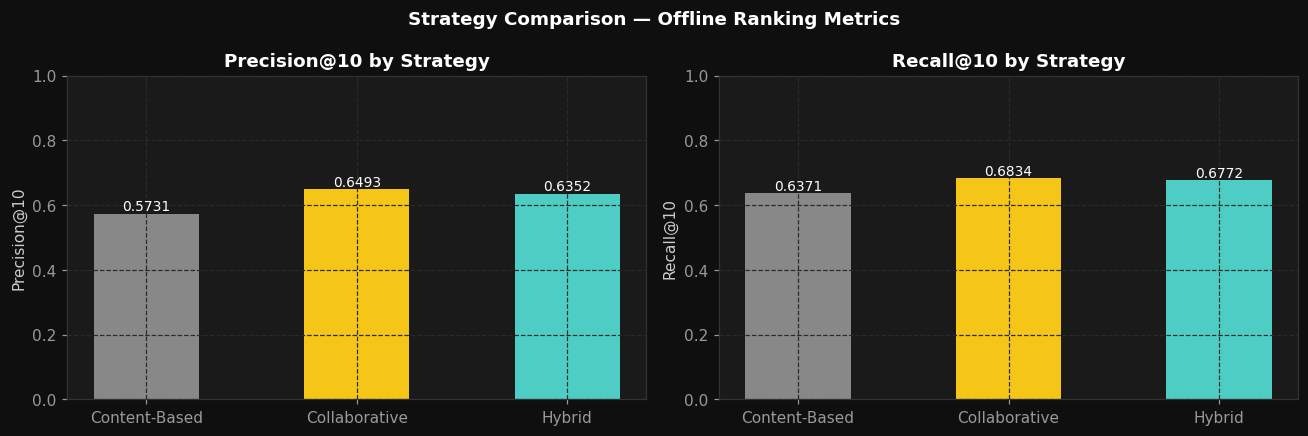

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
strategies = results_df['Strategy']
colors = ['#888', GOLD, '#4ecdc4']

for ax, metric in zip(axes, ['Precision@10', 'Recall@10']):
    bars = ax.bar(strategies, results_df[metric], color=colors, width=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric} by Strategy', color='white', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', color='white', fontsize=9)

plt.suptitle('Strategy Comparison — Offline Ranking Metrics', 
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'plots' / 'strategy_comparison.png',
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

In [21]:
coverage = eval_report['content_based']['coverage']
print(f"Content-based catalog coverage: {coverage:.4%}")
print()
print("Interpretation:")
print("  - Collaborative filtering achieves highest Precision@10 and Recall@10 for warm users")
print("  - Hybrid sits between both — its advantage is not visible in this metric because")
print("    Precision@K can only be computed for users with a held-out test set (warm users)")
print("  - For cold-start users (no history), collaborative filtering is undefined;")
print("    the hybrid system always returns a result via content-based or trending fallback")

Content-based catalog coverage: 58.9800%

Interpretation:
  - Collaborative filtering achieves highest Precision@10 and Recall@10 for warm users
  - Hybrid sits between both — its advantage is not visible in this metric because
    Precision@K can only be computed for users with a held-out test set (warm users)
  - For cold-start users (no history), collaborative filtering is undefined;
    the hybrid system always returns a result via content-based or trending fallback


## 8. Hybrid Recommendation Demo
Demonstrating all three recommendation modes: cold-start fallback, content-based, and personalised hybrid.


In [22]:
import requests

API = "http://localhost:8000"

def show_recs(endpoint, params, label):
    try:
        r = requests.get(f"{API}{endpoint}", params=params, timeout=5)
        data = r.json()
        print(f"\n{'='*60}")
        print(f"{label}")
        print(f"Strategy: {data['strategy_used']}  |  Results: {data['count']}")
        print(f"{'='*60}")
        for i, m in enumerate(data['results'][:5], 1):
            score_pct = int(m['score'] * 100)
            print(f"  {i}. {m['title']:<42s} [{score_pct}%]")
            print(f"     {m['reason']}")
    except Exception as e:
        print(f"API not running — start with: uvicorn api.main:app --port 8000")
        print(f"({e})")

show_recs('/trending', {'top_k': 5}, 'TRENDING (no user / no reference)')
show_recs('/recommend/content', {'title': 'Toy Story (1995)', 'top_k': 5}, 'CONTENT-BASED: Similar to Toy Story')
show_recs('/recommend/hybrid', {'user_id': 1, 'top_k': 5}, 'HYBRID: Personalised for User 1')


TRENDING (no user / no reference)
Strategy: fallback_popularity  |  Results: 5
  1. Shawshank Redemption, The (1994)           [84%]
     Popular and highly rated
  2. Godfather, The (1972)                      [82%]
     Popular and highly rated
  3. Fight Club (1999)                          [82%]
     Popular and highly rated
  4. Pulp Fiction (1994)                        [82%]
     Popular and highly rated
  5. Dark Knight, The (2008)                    [81%]
     Popular and highly rated

CONTENT-BASED: Similar to Toy Story
Strategy: content  |  Results: 5
  1. Wild, The (2006)                           [52%]
     Shares genre/theme with the selected movie
  2. Asterix and the Vikings (Astérix et les Vikings) (2006) [52%]
     Shares genre/theme with the selected movie
  3. Moana (2016)                               [52%]
     Shares genre/theme with the selected movie
  4. Toy Story 2 (1999)                         [49%]
     Shares genre/theme with the selected movie
  5. Twel

## 9. Summary

| Component | Detail |
|---|---|
| **Dataset 1** | MovieLens ml-latest-small — 100,836 ratings, 9,742 movies, 610 users |
| **Dataset 2** | TMDB 5000 — 4,803 movies with metadata (overview, keywords, cast, crew) |
| **Join coverage** | 3,537 movies with both rating history and content features |
| **Model 1** | Content-based filtering — CountVectorizer + cosine similarity |
| **Model 2** | Collaborative filtering — SVD (k=30 latent factors), RMSE = 0.8895 |
| **Model 3** | Hybrid — α-weighted blend, cold-start handling via α-table |
| **Precision@10** | Content: 0.5731 · Collaborative: 0.6493 · Hybrid: 0.6352 |
| **Recall@10** | Content: 0.6371 · Collaborative: 0.6834 · Hybrid: 0.6772 |
| **Coverage** | 58.98% of content-eligible catalog surfaced by content-based model |
| **Deployment** | FastAPI REST API + Streamlit web UI |

All models, evaluation results, and artifacts are reproducible by running the `src/` pipeline scripts in order:
```
python src/data_preprocessing.py
python src/content_based.py
python src/collaborative_filtering.py
python src/evaluate.py
```

> These reference figures are deterministic and reproducible across machines: `src/evaluate.py` uses a stable sort on `(rating desc, movie_id asc)` when selecting each user's seed movie, so re-running the pipeline locally will reproduce them exactly.
